### Test Dataset's Hyperbolicity

The key metric is Gromov's delta-hyperbolicity (δ), which measures how "tree-like" your data is. A value close to 0 means your data has hierarchical structure that hyperbolic embeddings will exploit well.

In [1]:
import numpy as np
from scipy.spatial import distance_matrix
from tqdm import tqdm
from PIL import Image
import torch
import torchvision.transforms.functional as TF
from rfdetr import RFDETRBase

# --- 1. delta hyperbolicity functions (from hyptorch/delta.py) ---

def delta_hyp(dismat):
    """Computes delta hyperbolicity from a distance matrix."""
    p = 0
    row = dismat[p, :][np.newaxis, :]
    col = dismat[:, p][:, np.newaxis]
    XY_p = 0.5 * (row + col - dismat)
    maxmin = np.max(np.minimum(XY_p[:, :, None], XY_p[None, :, :]), axis=1)
    return np.max(maxmin - XY_p)


def batched_delta_hyp(X, n_tries=10, batch_size=1500):
    """Computes relative delta hyperbolicity with random sampling."""
    vals = []
    for i in tqdm(range(n_tries)):
        idx = np.random.choice(len(X), min(batch_size, len(X)), replace=False)
        X_batch = X[idx]
        distmat = distance_matrix(X_batch, X_batch)
        diam = np.max(distmat)
        if diam > 0:
            delta_rel = 2 * delta_hyp(distmat) / diam
            vals.append(delta_rel)
    return np.mean(vals), np.std(vals)


In [3]:
# --- 2. Extract decoder features from your trained model ---

model = RFDETRBase(pretrain_weights="output/checkpoint_best_total.pth")
model.model.model.eval()
device = model.model.device

# Load your dataset images
import os, json, cv2
dataset_dir = "Veiculos-Contar-3"  
with open(os.path.join(dataset_dir, "train", "_annotations.coco.json")) as f:
    ann = json.load(f)

print(f"Train images: {len(ann['images'])}")

# Count annotations per class
from collections import Counter
class_counts = Counter(a["category_id"] for a in ann["annotations"])
class_names = {c["id"]: c["name"] for c in ann["categories"]}
for cid, count in sorted(class_counts.items()):
    print(f"  {class_names[cid]:15s}: {count} annotations")

all_features = []
all_labels = []

# Build image_id -> annotations lookup
img_id_to_anns = {}
for a in ann["annotations"]:
    img_id_to_anns.setdefault(a["image_id"], []).append(a)

with torch.no_grad():
    for img_info in tqdm(ann["images"][:500]):
        img_path = os.path.join(dataset_dir, "train", img_info["file_name"])
        pil_img = Image.open(img_path).convert("RGB")

        # Preprocess the same way RF-DETR does
        img_tensor = TF.to_tensor(pil_img).to(device)
        img_tensor = TF.normalize(
            img_tensor,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )
        img_tensor = torch.nn.functional.interpolate(
            img_tensor.unsqueeze(0),
            size=(model.model.resolution, model.model.resolution),
            mode="bilinear",
        )

        # Forward through backbone + transformer decoder (but NOT class_embed)
        from rfdetr.util.misc import nested_tensor_from_tensor_list
        samples = nested_tensor_from_tensor_list(img_tensor)
        features, poss = model.model.model.backbone(samples)
        srcs = [feat.decompose()[0] for feat in features]
        masks = [feat.decompose()[1] for feat in features]

        refpoint = model.model.model.refpoint_embed.weight[:model.model.model.num_queries]
        query_feat = model.model.model.query_feat.weight[:model.model.model.num_queries]

        hs, _, _, _ = model.model.model.transformer(
            srcs, masks, poss, refpoint, query_feat
        )

        # hs shape: [dec_layers, 1, num_queries, hidden_dim]
        # Take last decoder layer, squeeze batch
        decoder_features = hs[-1].squeeze(0)  # [300, 256]

        # Get the class predictions to filter high-confidence detections
        logits = model.model.model.class_embed(hs[-1]).squeeze(0)  # [300, num_classes]
        scores = logits.sigmoid().max(dim=-1)
        conf = scores.values   # [300]
        # Debug: see what confidence scores look like
        if img_info == ann["images"][0]:
            print(f"Max confidence: {conf.max().item():.4f}")
            print(f"Detections > 0.1: {(conf > 0.1).sum().item()}")
            print(f"Detections > 0.3: {(conf > 0.3).sum().item()}")
        classes = scores.indices  # [300]

                # Lower threshold to capture more detections
        keep = conf > 0.1  # lowered from 0.3

        if keep.sum() > 0:
            all_features.append(decoder_features[keep].cpu().numpy())
            all_labels.append(classes[keep].cpu().numpy())

    # After the loop, check what we got
    print(f"Images processed: {len(ann['images'][:500])}")
    print(f"Feature batches collected: {len(all_features)}")

    if len(all_features) == 0:
        raise RuntimeError(
            "No detections found. Try using model.predict() on a single image first "
            "to verify the model is working correctly."
        )

all_features = np.concatenate(all_features, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

Reinitializing detection head with 8 classes


Loading pretrain weights
Train images: 5528
  Bus            : 115 annotations
  Motorcycle     : 400 annotations
  Pickup         : 11049 annotations
  Sedan          : 10840 annotations
  Suv            : 2152 annotations
  Truck          : 5248 annotations
  Van            : 1551 annotations


  0%|          | 1/500 [00:00<03:36,  2.31it/s]

Max confidence: 0.7809
Detections > 0.1: 3
Detections > 0.3: 2


100%|██████████| 500/500 [03:16<00:00,  2.55it/s]

Images processed: 500
Feature batches collected: 500


In [5]:
# --- 3. Compute delta hyperbolicity ---

mean_delta, std_delta = batched_delta_hyp(all_features, n_tries=30, batch_size=1000)
print(f"Relative delta hyperbolicity: {mean_delta:.6f} +/- {std_delta:.6f}")

100%|██████████| 30/30 [01:41<00:00,  3.39s/it]

Relative delta hyperbolicity: 0.385328 +/- 0.020822


### Replace class_embed with a HypLL-based hyperbolic classification head

In [1]:
import math
import torch
import torch.nn as nn
from hypll.manifolds.poincare_ball import Curvature, PoincareBall
from hypll.manifolds.poincare_ball.math.diffgeom import expmap0, project
from hypll.manifolds.poincare_ball.math.linalg import poincare_hyperplane_dists


class HyperbolicDETRHead(nn.Module):
    """
    Hyperbolic classification head for RF-DETR using HypLL's Poincare ball.

    Replaces nn.Linear class_embed with HNN++ hyperbolic hyperplane classification.
    Features are mapped to the Poincare ball via expmap, then classified using
    signed geodesic distances to learnable hyperbolic hyperplanes.

    Well-suited for hierarchical vehicle classes:
      Passenger (Sedan, SUV, Pickup) / Commercial (Van, Truck, Bus) / Motorcycle
    """

    def __init__(self, input_dim, num_classes, curvature=0.1):
        super().__init__()
        self.input_dim = input_dim
        self.num_classes = num_classes

        # HypLL Poincare ball manifold (fixed curvature — no RiemannianAdam needed)
        self.manifold = PoincareBall(c=Curvature(value=curvature, requires_grad=False))

        # Euclidean projection to prepare features for hyperbolic mapping
        self.proj = nn.Linear(input_dim, input_dim)

        # Hyperplane orientation vectors z_k for each class
        # Shape: [input_dim, num_classes], manifold dim = 0
        self.z = nn.Parameter(torch.empty(input_dim, num_classes))
        nn.init.normal_(self.z, mean=0, std=(2 * input_dim * num_classes) ** -0.5)

        # Hyperplane offsets in hyperbolic space
        self.r = nn.Parameter(torch.zeros(num_classes))

        # Euclidean bias added to logits (for focal loss initialization)
        self.bias = nn.Parameter(torch.zeros(num_classes))

    def forward(self, x):
        """
        Args:
            x: [..., input_dim]  e.g. [dec_layers, batch, queries, 256]
        Returns:
            logits: [..., num_classes]  compatible with sigmoid focal loss
        """
        leading_shape = x.shape[:-1]
        D = x.shape[-1]

        x_flat = x.reshape(-1, D)           # [N, D]

        x_proj = self.proj(x_flat)           # [N, D]

        c = self.manifold.c()                # curvature scalar tensor

        # Map to Poincare ball via exponential map at origin
        x_ball = expmap0(x_proj, c, dim=-1)  # [N, D], guaranteed on ball

        # HNN++ classification: signed distances to hyperbolic hyperplanes
        hyp_logits = poincare_hyperplane_dists(
            x_ball, self.z, self.r, c, dim=-1
        )                                    # [N, num_classes]

        # Add Euclidean bias (initialized for focal loss)
        logits = hyp_logits + self.bias

        return logits.reshape(*leading_shape, self.num_classes)

###  Monkey-patch reinitialize_detection_head

In [2]:
import types

def _hyp_reinit_detection_head(self, num_classes):
    """Override: create hyperbolic head instead of nn.Linear."""
    del self.class_embed
    hyp_head = HyperbolicDETRHead(
        input_dim=self.transformer.d_model,
        num_classes=num_classes,
        curvature=0.1,
    )
    self.add_module("class_embed", hyp_head)

    # Focal loss bias init (same as original RF-DETR)
    prior_prob = 0.01
    bias_value = -math.log((1 - prior_prob) / prior_prob)
    with torch.no_grad():
        self.class_embed.bias.data.fill_(bias_value)

    # Handle two-stage if applicable
    if self.two_stage:
        import copy
        del self.transformer.enc_out_class_embed
        self.transformer.add_module(
            "enc_out_class_embed",
            nn.ModuleList(
                [copy.deepcopy(self.class_embed) for _ in range(self.group_detr)]
            ),
        )
    print(f"Hyperbolic head initialized: {num_classes} classes, dim={self.transformer.d_model}")

### Load dataset

In [3]:
from roboflow import Roboflow
rf = Roboflow(api_key="sjKAVuO8Lkaq5h2dDfDA")
project = rf.workspace("fyp-vfrgn").project("veiculos-contar-dnosk")
version = project.version(3)
dataset = version.download("coco")

loading Roboflow workspace...
loading Roboflow project...


### Instantiate the model

In [4]:
from rfdetr import RFDETRBase

model = RFDETRBase(pretrain_weights="rf-detr-base.pth")

# Apply to the LWDETR model inside RFDETRBase instance
model.model.model.reinitialize_detection_head = types.MethodType(
    _hyp_reinit_detection_head, model.model.model
)

Loading pretrain weights


### Free up GPU memory

In [13]:
import gc
import torch
import weakref

def cleanup_gpu_memory(obj=None, verbose: bool = False):

    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    # Ensure we drop all strong references
    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [14]:
cleanup_gpu_memory(model, verbose=True)

[Before] Allocated: 272.71 MB | Reserved: 6756.00 MB
[WARNING] Object not fully garbage collected yet.
[After]  Allocated: 272.71 MB | Reserved: 320.00 MB


### Train

In [8]:
history = []

def callback2(data):
	history.append(data)

model.callbacks["on_fit_epoch_end"].append(callback2)

model.train(
    dataset_dir=dataset.location,
    epochs=30,
    batch_size=4,
    grad_accum_steps=4,
    lr=1e-4,
    lr_encoder=1.5e-4,
    weight_decay=1e-4,
    amp=True,
)

num_classes mismatch: model has 90 classes, but your dataset has 8 classes
reinitializing your detection head with 8 classes.


Hyperbolic head initialized: 8 classes, dim=256
Unable to initialize TensorBoard. Logging is turned off for this session.  Run 'pip install tensorboard' to enable logging.
Not using distributed mode
git:
  sha: 0744aeb089111206735b55b0c70c64d34de6ec83, status: clean, branch: hyperbolic_learning

Namespace(num_classes=8, grad_accum_steps=4, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=4, weight_decay=0.0001, epochs=30, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-base.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[2, 5, 8, 11], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, forc

Epoch: [0]  [  0/345]  eta: 1:47:01  lr: 0.000100  class_error: 79.26  loss: 11.4000 (11.4000)  loss_ce: 0.8062 (0.8062)  loss_bbox: 0.6558 (0.6558)  loss_giou: 1.2105 (1.2105)  loss_ce_0: 0.8077 (0.8077)  loss_bbox_0: 0.8498 (0.8498)  loss_giou_0: 1.3386 (1.3386)  loss_ce_1: 0.7908 (0.7908)  loss_bbox_1: 0.7077 (0.7077)  loss_giou_1: 1.2915 (1.2915)  loss_ce_enc: 0.8337 (0.8337)  loss_bbox_enc: 0.7861 (0.7861)  loss_giou_enc: 1.3215 (1.3215)  loss_ce_unscaled: 0.8062 (0.8062)  class_error_unscaled: 79.2642 (79.2642)  loss_bbox_unscaled: 0.1312 (0.1312)  loss_giou_unscaled: 0.6052 (0.6052)  cardinality_error_unscaled: 3871.5000 (3871.5000)  loss_ce_0_unscaled: 0.8077 (0.8077)  loss_bbox_0_unscaled: 0.1700 (0.1700)  loss_giou_0_unscaled: 0.6693 (0.6693)  cardinality_error_0_unscaled: 3763.2500 (3763.2500)  loss_ce_1_unscaled: 0.7908 (0.7908)  loss_bbox_1_unscaled: 0.1415 (0.1415)  loss_giou_1_unscaled: 0.6458 (0.6458)  cardinality_error_1_unscaled: 3867.7500 (3867.7500)  loss_ce_enc_uns

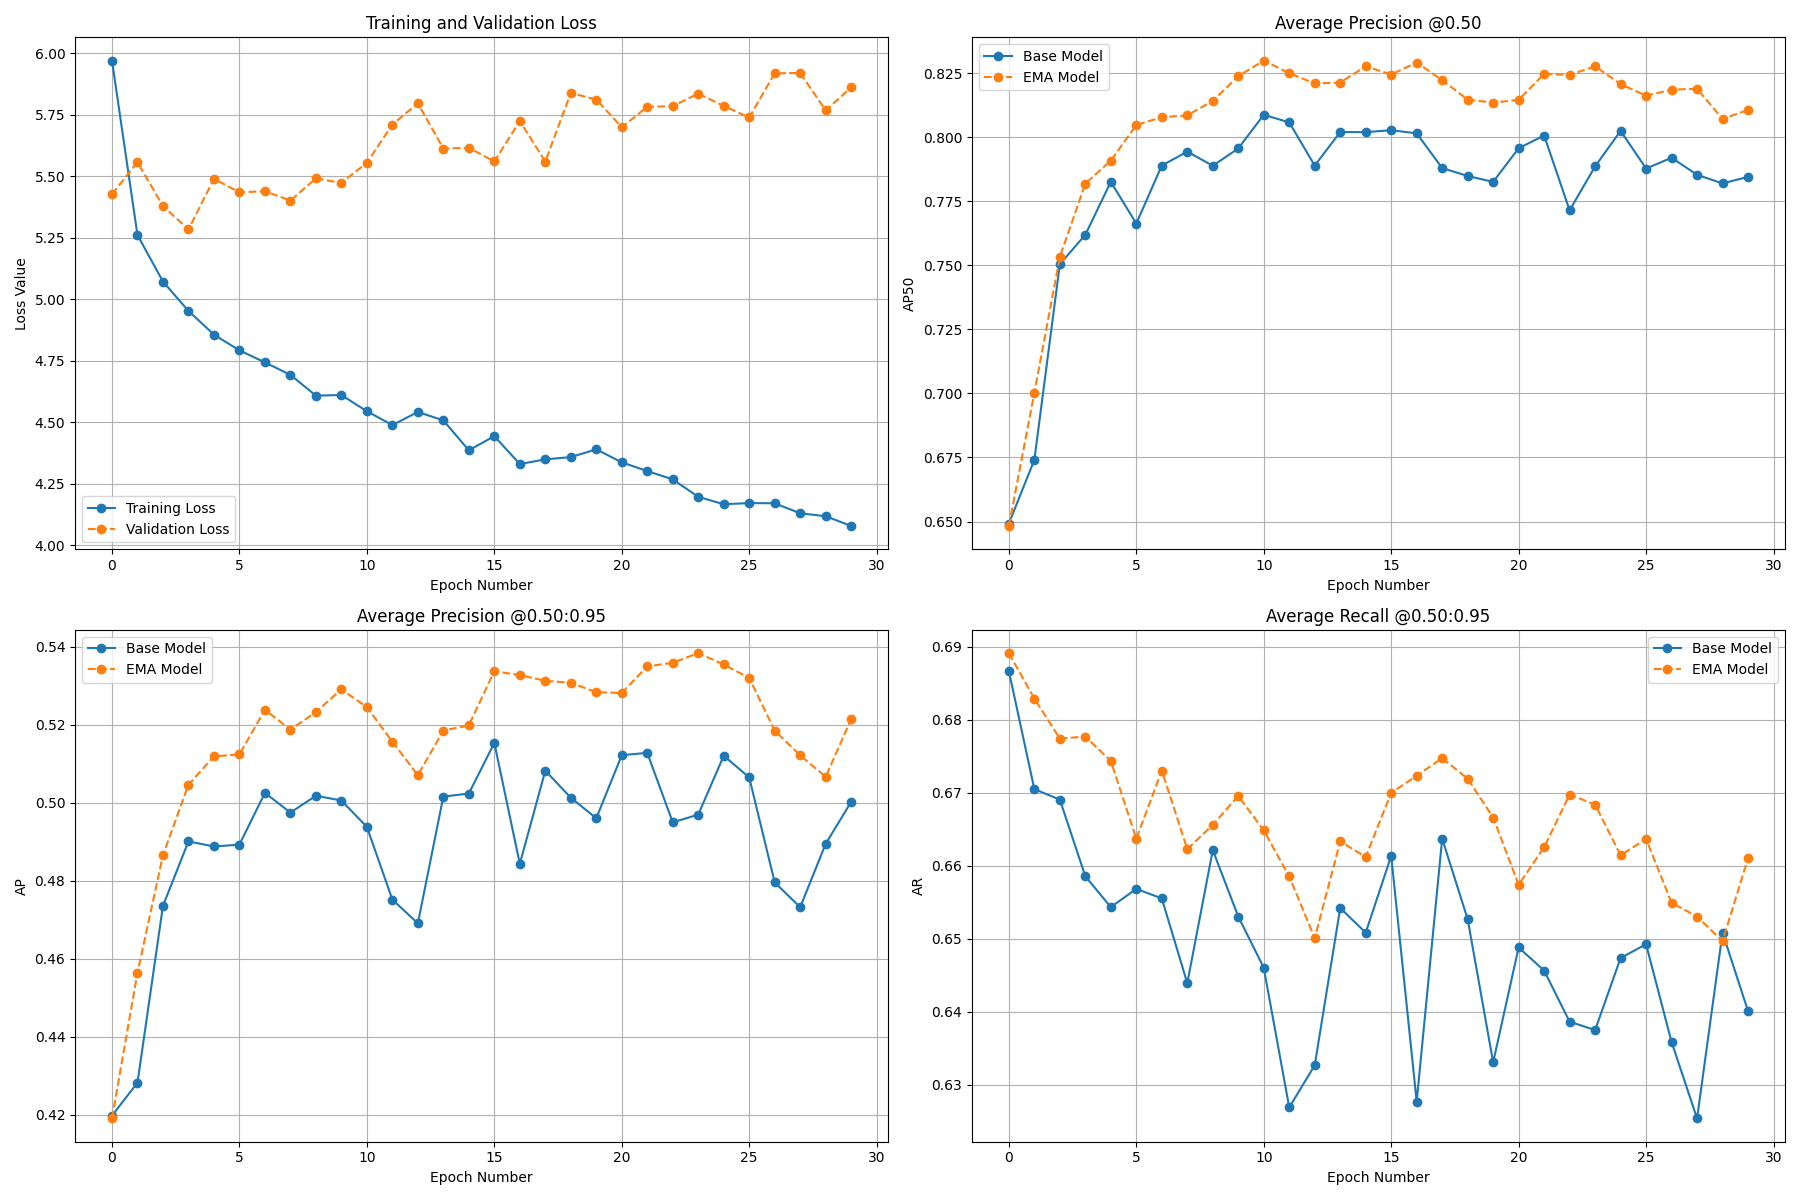

In [9]:
from PIL import Image

Image.open("output/metrics_plot.png")

In [15]:
## Evaluate Fine-tuned RF-DETR Model
from rfdetr import RFDETRBase
model = RFDETRBase(pretrain_weights="output/checkpoint_best_total.pth")
model.model.model.reinitialize_detection_head = types.MethodType(
    _hyp_reinit_detection_head, model.model.model
)
model.optimize_for_inference()
import supervision as sv

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision

targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    image = Image.open(path)
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)
map_metric = MeanAveragePrecision()
map_result = map_metric.update(predictions, targets).compute()
print(map_result)

Loading pretrain weights


num_classes mismatch: pretrain weights has 7 classes, but your model has 90 classes
reinitializing detection head with 7 classes
100%|██████████| 290/290 [00:10<00:00, 27.17it/s]


Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.011
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.024
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.008
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.008
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.014
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.018
